In [33]:
# all the imports needed.
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

In [34]:
# Downloading the data, augmenting the training data for better learning
transformer_train = transforms.Compose(
    [
        transforms.RandomRotation(10),
        #transforms.RandomResizedCrop(28),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, ), (0.5, ))
    ]
)

transformer_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5, ))
    ]
)

train_dataset = datasets.MNIST(root = 'data', train = True, download = True, transform = transformer_train)
test_dataset = datasets.MNIST(root = 'data', train = False, download = True, transform = transformer_test)

In [35]:
# Making Dataloaders to easily iterate through the datasets.
batch_size = 64

from torch.utils.data import DataLoader

train_loader = DataLoader(dataset= train_dataset, batch_size= batch_size, shuffle = True)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [36]:
# assigning to gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


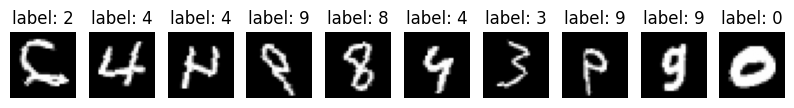

In [37]:
# Loading a few images to visualize the data


def show_images(images, labels):
  fig, axes = plt.subplots(1, len(images), figsize = (10, 2))
  for img, label, ax in zip(images, labels, axes):
    ax.imshow(img.squeeze(), cmap = 'gray')
    ax.set_title(f'label: {label}')
    ax.axis('off')
  plt.show()

# Get a batch of train data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Plot 5 images with labels
show_images(images[:10], labels[:10])

In [38]:
# Building the Neural Network

class NNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    # input layer
    self.fc1 = nn.Linear(28 * 28, 392) #392

    # hidden layers
    self.fc2 = nn.Linear(392, 128)
    self.fc3 = nn.Linear(128, 64)

    # output layer
    self.fc4 = nn.Linear(64, 10)

    #defining dropout
    self.dropout = nn.Dropout(0.2)

  def forward(self, x):
    x = x.view(x.shape[0], -1)

    #x = self.dropout(x)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.dropout(x)
    x = F.relu(self.fc3(x))
    x = F.log_softmax(self.fc4(x), dim = 1)

    return x

model = NNetwork()
model.to(device)


NNetwork(
  (fc1): Linear(in_features=784, out_features=392, bias=True)
  (fc2): Linear(in_features=392, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [39]:
# define the loss and optimizer

criterion = nn.NLLLoss()

optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [40]:
# lets start training

train_loss_history = []
test_loss_history = []

epochs = 30

for epoch in range(epochs):
  train_loss = 0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    prediction = model(images)

    loss = criterion(prediction, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  else:
    test_loss = 0
    accuracy = 0


    with torch.no_grad():
      model.eval()
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        log_ps = model(images)
        test_loss += criterion(log_ps, labels).item()

        ps = torch.exp(log_ps)
        top_p, top_class = ps.topk(1, dim = 1)
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor))

  model.train()

  train_loss_history.append(train_loss / len(train_loader))
  test_loss_history.append(test_loss / len(test_loader))

  print('Epoch: {}/{}..'.format(epoch + 1, epochs),
        "Training loss: {:.3f}".format(train_loss / len(train_loader)),
        "Test loss: {:.3f}".format(test_loss / len(test_loader)),
        "accuracy: {:.3f}".format(accuracy / len(test_loader)))

Epoch: 1/30.. Training loss: 0.636 Test loss: 0.311 accuracy: 0.899
Epoch: 2/30.. Training loss: 0.358 Test loss: 0.223 accuracy: 0.930
Epoch: 3/30.. Training loss: 0.296 Test loss: 0.194 accuracy: 0.938
Epoch: 4/30.. Training loss: 0.264 Test loss: 0.159 accuracy: 0.950
Epoch: 5/30.. Training loss: 0.242 Test loss: 0.179 accuracy: 0.942
Epoch: 6/30.. Training loss: 0.229 Test loss: 0.153 accuracy: 0.952
Epoch: 7/30.. Training loss: 0.215 Test loss: 0.146 accuracy: 0.953
Epoch: 8/30.. Training loss: 0.209 Test loss: 0.141 accuracy: 0.954
Epoch: 9/30.. Training loss: 0.198 Test loss: 0.127 accuracy: 0.960
Epoch: 10/30.. Training loss: 0.188 Test loss: 0.118 accuracy: 0.963
Epoch: 11/30.. Training loss: 0.188 Test loss: 0.117 accuracy: 0.965
Epoch: 12/30.. Training loss: 0.180 Test loss: 0.110 accuracy: 0.966
Epoch: 13/30.. Training loss: 0.172 Test loss: 0.110 accuracy: 0.966
Epoch: 14/30.. Training loss: 0.171 Test loss: 0.122 accuracy: 0.962
Epoch: 15/30.. Training loss: 0.168 Test lo

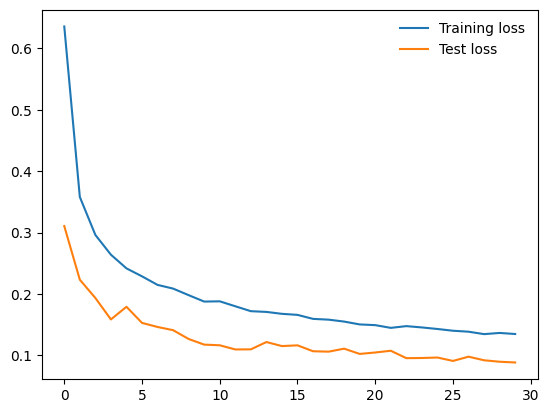

In [41]:
plt.plot(train_loss_history, label = 'Training loss')
plt.plot(test_loss_history, label = 'Test loss')
plt.legend(frameon = False)

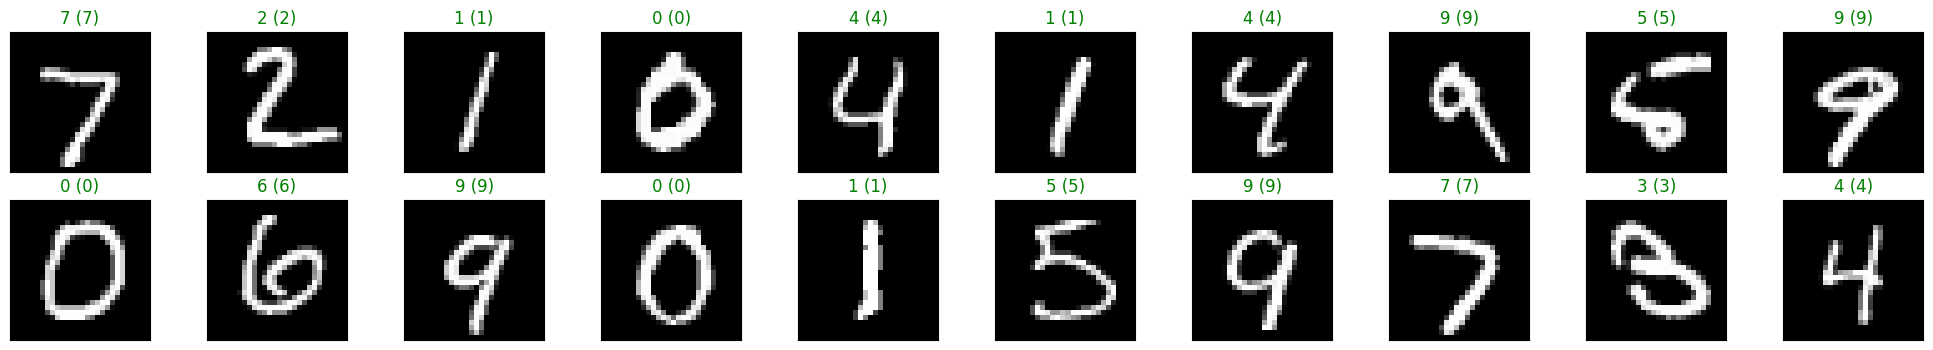

In [42]:
# test it out

dataiter = iter(test_loader)
img, labels = next(dataiter)
img = img.to(device)
model.eval()
output = model(img)
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.to('cpu').numpy())
img = img.to('cpu')

fig = plt.figure(figsize =(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 20 // 2, idx +1, xticks = [], yticks = [])
  ax.imshow(img[idx].squeeze(), cmap = 'gray')
  ax.set_title('{} ({})'.format(str(preds[idx].item()), str(labels[idx].item())), color = ('green' if preds[idx] == labels[idx].item() else 'red'))

In [43]:
torch.save(model.state_dict(), 'basic_MLP.pth')